# 05. Repeat Purchase Classification

Xây dựng mô hình phân loại dự đoán khách hàng có tiếp tục quay lại mua sắm trong kỳ tiếp theo hay không.


In [1]:
# Setup environment and imports
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src import config


## 1. Tạo Nhãn & Tập Dữ Liệu Mua Lại


In [2]:
from src.data_loader import load_processed_data

# Tải trực tiếp tập dữ liệu đã được pipeline xử lý sẵn
df_repeat = load_processed_data('repeat_purchase_features.csv')

print(f"Kích thước tập dữ liệu: {df_repeat.shape}")
df_repeat.head()

Kích thước tập dữ liệu: (3368, 13)


,CustomerID,Recency,Frequency,Monetary,TotalItems,UniqueProducts,UniqueInvoices,ActiveDays,Country,AverageOrderValue,AverageItemsPerInvoice,CustomerLifetimeDays,repeat_purchase_90d
0,12346,236,1,77183.60,74215,1,1,1,United Kingdom,77183.6000,74215.000000,0,0
1,12347,40,5,2790.86,1590,82,5,5,Iceland,558.1720,318.000000,237,1
2,12348,159,3,1167.24,2116,21,3,3,Finland,389.0800,705.333333,109,1
3,12350,220,1,294.40,196,16,1,1,Norway,294.4000,196.000000,0,0
4,12352,172,4,641.51,249,24,4,4,Norway,160.3775,62.250000,34,1


## 2. Huấn Luyện Các Mô Hình Phân Loại


In [3]:
from src.classification import train_and_compare_models

# Lấy thêm X_test và y_test để dùng cho phần đánh giá
results, trained_models, X_test, y_test = train_and_compare_models(
    df_repeat, 
    target_col='repeat_purchase_90d'
)

print("\n--- BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH ---")
display(results)

Đang chuẩn bị dữ liệu...
Đang huấn luyện các mô hình...


d:\HK1 2026-2027\KTDL\Data-mining\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[OK] Đã lưu mô hình tốt nhất (Gradient Boosting) tại D:\HK1 2026-2027\KTDL\Data-mining\models\classification\best_classifier.pkl

--- BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH ---


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.6973,0.7368,0.7292,0.7330
Random Forest,0.6706,0.7035,0.7292,0.7161
Gradient Boosting,0.7033,0.7383,0.7422,0.7403


## 3. Đánh Giá Ma Trận Nhầm Lẫn (Confusion Matrix)


--- ĐÁNH GIÁ MÔ HÌNH: Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.66      0.65      0.65       290
           1       0.74      0.74      0.74       384

    accuracy                           0.70       674
   macro avg       0.70      0.70      0.70       674
weighted avg       0.70      0.70      0.70       674



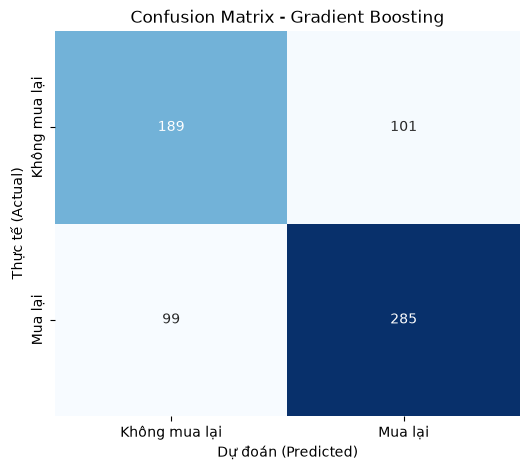

In [4]:
from src.evaluation import evaluate_classification_model

# Lấy mô hình có điểm F1 cao nhất từ bảng kết quả
best_model_name = results['F1-Score'].idxmax()
best_model = trained_models[best_model_name]

# Chạy hàm đánh giá và lưu ảnh
evaluate_classification_model(
    model=best_model, 
    X_test=X_test, 
    y_test=y_test, 
    model_name=best_model_name,
    save_dir='../outputs/figures/classification'
)

## 4. Lưu Trọng Số Mô Hình


In [5]:
print('Mô hình hoàn thành huấn luyện và lưu trữ trong models/classification/')

Mô hình hoàn thành huấn luyện và lưu trữ trong models/classification/
